In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.fft import fft, fftfreq

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
PLOT_DPI = 100

DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2.csv"

In [3]:
dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Vibration_pu_Pressure,Engine_Temperature_pu_Power,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.16975,1.402774,90.6454,26.8508,238.852,122.664,110.082728,0.011436,...,0.039700,0.205773,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.075574,0.225304,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.07999,0.746920,90.7978,26.8639,227.943,122.338,109.588508,0.006105,...,0.075574,0.225304,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.52577,1.402774,90.7730,26.8603,223.486,121.338,88.482324,0.011561,...,0.039724,0.189188,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.49742,1.074847,90.8424,26.8616,244.904,121.664,98.062801,0.008835,...,0.052677,0.174736,0.000339,0.06556,0.004268,0.23928,42.844684,64.762931,0.0,No Anomaly


In [4]:
dataframe_anomaly = dataframe[["anomaly", "description"]]
dataframe.drop(columns=["anomaly", "description"], inplace=True)

In [5]:
def fast_fourier_transform(df):
    # Sampling rate
    sampling_rate = 1  # Hz (1 sample per second)
    time_step = 1 / sampling_rate # seconds per sample
    num_samples = df.shape[0]  # Total number of samples

    # --- Extract data from DataFrame columns for FFT ---
    accel1_rms = df['Accelerometer1RMS'].values
    accel2_rms = df['Accelerometer2RMS'].values

    # --- 2. Perform FFT for Accelerometer1RMS ---
    print("Performing FFT for Accelerometer1RMS (including negative frequencies)...")
    # Compute the FFT
    yf1 = fft(accel1_rms)
    # Compute the frequencies corresponding to the FFT output for both positive and negative frequencies
    xf1 = fftfreq(num_samples, time_step)

    # Calculate the magnitude (amplitude) spectrum - no multiplication by 2 for two-sided spectrum
    magnitude_spectrum1 = np.abs(yf1) / num_samples

    # --- 3. Perform FFT for Accelerometer2RMS ---
    print("Performing FFT for Accelerometer2RMS (including negative frequencies)...")
    # Compute the FFT
    yf2 = fft(accel2_rms)
    # Compute the frequencies corresponding to the FFT output for both positive and negative frequencies
    xf2 = fftfreq(num_samples, time_step) # Should be the same as xf1

    # Calculate the magnitude (amplitude) spectrum
    magnitude_spectrum2 = np.abs(yf2) / num_samples

    print("FFT Complete.")
    print("-" * 30)

    # --- 4. Plotting the Results ---

    plt.figure(figsize=(14, 12))

    # Plot Time Domain Data
    plt.subplot(3, 1, 1)
    plt.plot(df.index, df['Accelerometer1RMS'], label='Accelerometer1RMS')
    plt.plot(df.index, df['Accelerometer2RMS'], label='Accelerometer2RMS', alpha=0.7)
    plt.title('Time Domain Vibration Data (Placeholder)')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Acceleration (g)')
    plt.grid(True)
    plt.legend()

    # Plot Frequency Domain Data for Accelerometer1RMS (including negative frequencies)
    plt.subplot(3, 1, 2)
    # Sort by frequency for proper plotting
    sort_indices1 = np.argsort(xf1)
    plt.plot(xf1[sort_indices1], magnitude_spectrum1[sort_indices1])
    plt.title('Frequency Domain (FFT) - Accelerometer1RMS (Full Spectrum)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude (g)')
    plt.grid(True)
    plt.xlim(-sampling_rate / 2, sampling_rate / 2) # Show full range from -Nyquist to +Nyquist

    # Plot Frequency Domain Data for Accelerometer2RMS (including negative frequencies)
    plt.subplot(3, 1, 3)
    # Sort by frequency for proper plotting
    sort_indices2 = np.argsort(xf2)
    plt.plot(xf2[sort_indices2], magnitude_spectrum2[sort_indices2], color='orange')
    plt.title('Frequency Domain (FFT) - Accelerometer2RMS (Full Spectrum)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude (g)')
    plt.grid(True)
    plt.xlim(-sampling_rate / 2, sampling_rate / 2) # Show full range from -Nyquist to +Nyquist

    plt.tight_layout()
    plt.show()

    # --- 5. Interpretation ---
    print("\n--- Interpretation of FFT Results (Full Spectrum) ---")
    print("The plots above now show the full frequency content, including both positive and negative frequencies.")
    print(f"The frequency range displayed is from -{sampling_rate / 2} Hz to +{sampling_rate / 2} Hz.")
    print("For real-valued signals, the magnitude spectrum is symmetric around 0 Hz, meaning the negative frequency components are a mirror image of the positive frequency components.")

    print("\nFor Accelerometer1RMS (Positive Frequencies):")
    # Find the dominant frequency and its amplitude in the positive frequency range
    positive_xf1_indices = np.where(xf1 >= 0)
    positive_xf1 = xf1[positive_xf1_indices]
    positive_magnitude_spectrum1 = magnitude_spectrum1[positive_xf1_indices]
    dom_freq1_idx = np.argmax(positive_magnitude_spectrum1)
    dom_freq1 = positive_xf1[dom_freq1_idx]
    dom_amp1 = positive_magnitude_spectrum1[dom_freq1_idx] * 2 # Multiply by 2 for the single-sided amplitude
    print(f"  Dominant positive frequency: {dom_freq1:.3f} Hz with amplitude (single-sided): {dom_amp1:.3f} g")

    print("\nFor Accelerometer2RMS (Positive Frequencies):")
    # Find the dominant frequency and its amplitude in the positive frequency range
    positive_xf2_indices = np.where(xf2 >= 0)
    positive_xf2 = xf2[positive_xf2_indices]
    positive_magnitude_spectrum2 = magnitude_spectrum2[positive_xf2_indices]
    dom_freq2_idx = np.argmax(positive_magnitude_spectrum2)
    dom_freq2 = positive_xf2[dom_freq2_idx]
    dom_amp2 = positive_magnitude_spectrum2[dom_freq2_idx] * 2 # Multiply by 2 for the single-sided amplitude
    print(f"  Dominant positive frequency: {dom_freq2:.3f} Hz with amplitude (single-sided): {dom_amp2:.3f} g")

    print("\nWhile the full spectrum shows symmetry, for practical interpretation of a real-valued signal, we usually focus on the positive frequencies because they contain all the unique information about the signal's frequency content.")

Performing FFT for Accelerometer1RMS (including negative frequencies)...
Performing FFT for Accelerometer2RMS (including negative frequencies)...
FFT Complete.
------------------------------


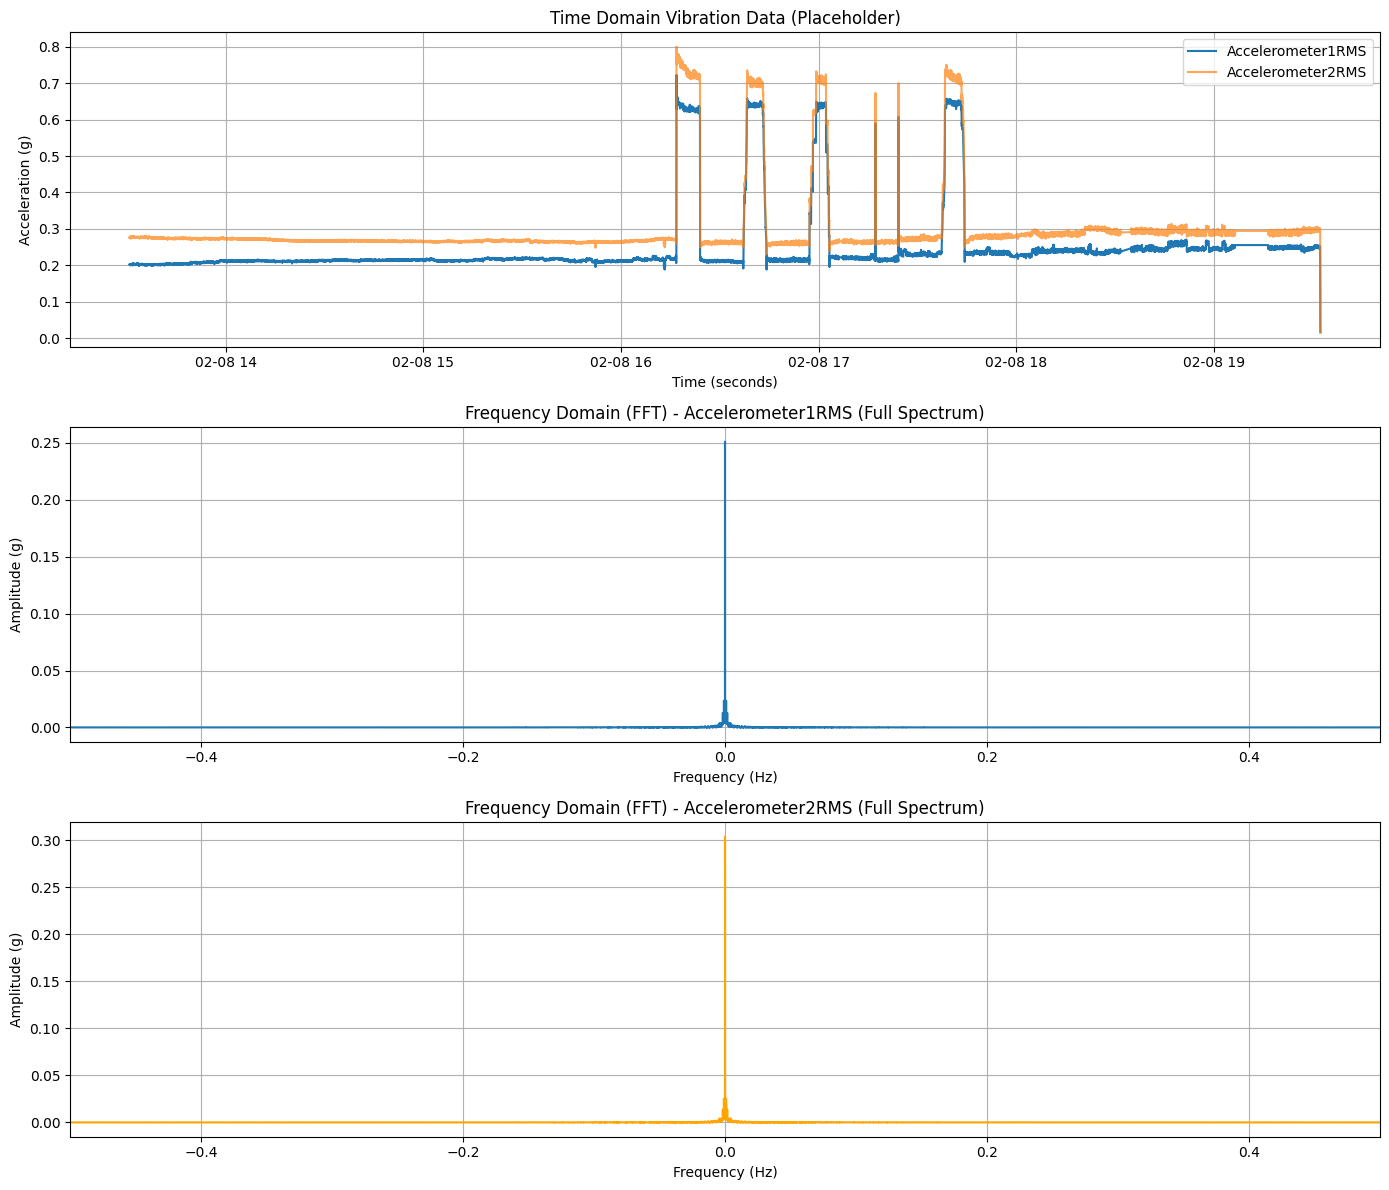


--- Interpretation of FFT Results (Full Spectrum) ---
The plots above now show the full frequency content, including both positive and negative frequencies.
The frequency range displayed is from -0.5 Hz to +0.5 Hz.
For real-valued signals, the magnitude spectrum is symmetric around 0 Hz, meaning the negative frequency components are a mirror image of the positive frequency components.

For Accelerometer1RMS (Positive Frequencies):
  Dominant positive frequency: 0.000 Hz with amplitude (single-sided): 0.502 g

For Accelerometer2RMS (Positive Frequencies):
  Dominant positive frequency: 0.000 Hz with amplitude (single-sided): 0.607 g

While the full spectrum shows symmetry, for practical interpretation of a real-valued signal, we usually focus on the positive frequencies because they contain all the unique information about the signal's frequency content.
Performing FFT for Accelerometer1RMS (including negative frequencies)...
Performing FFT for Accelerometer2RMS (including negative fre

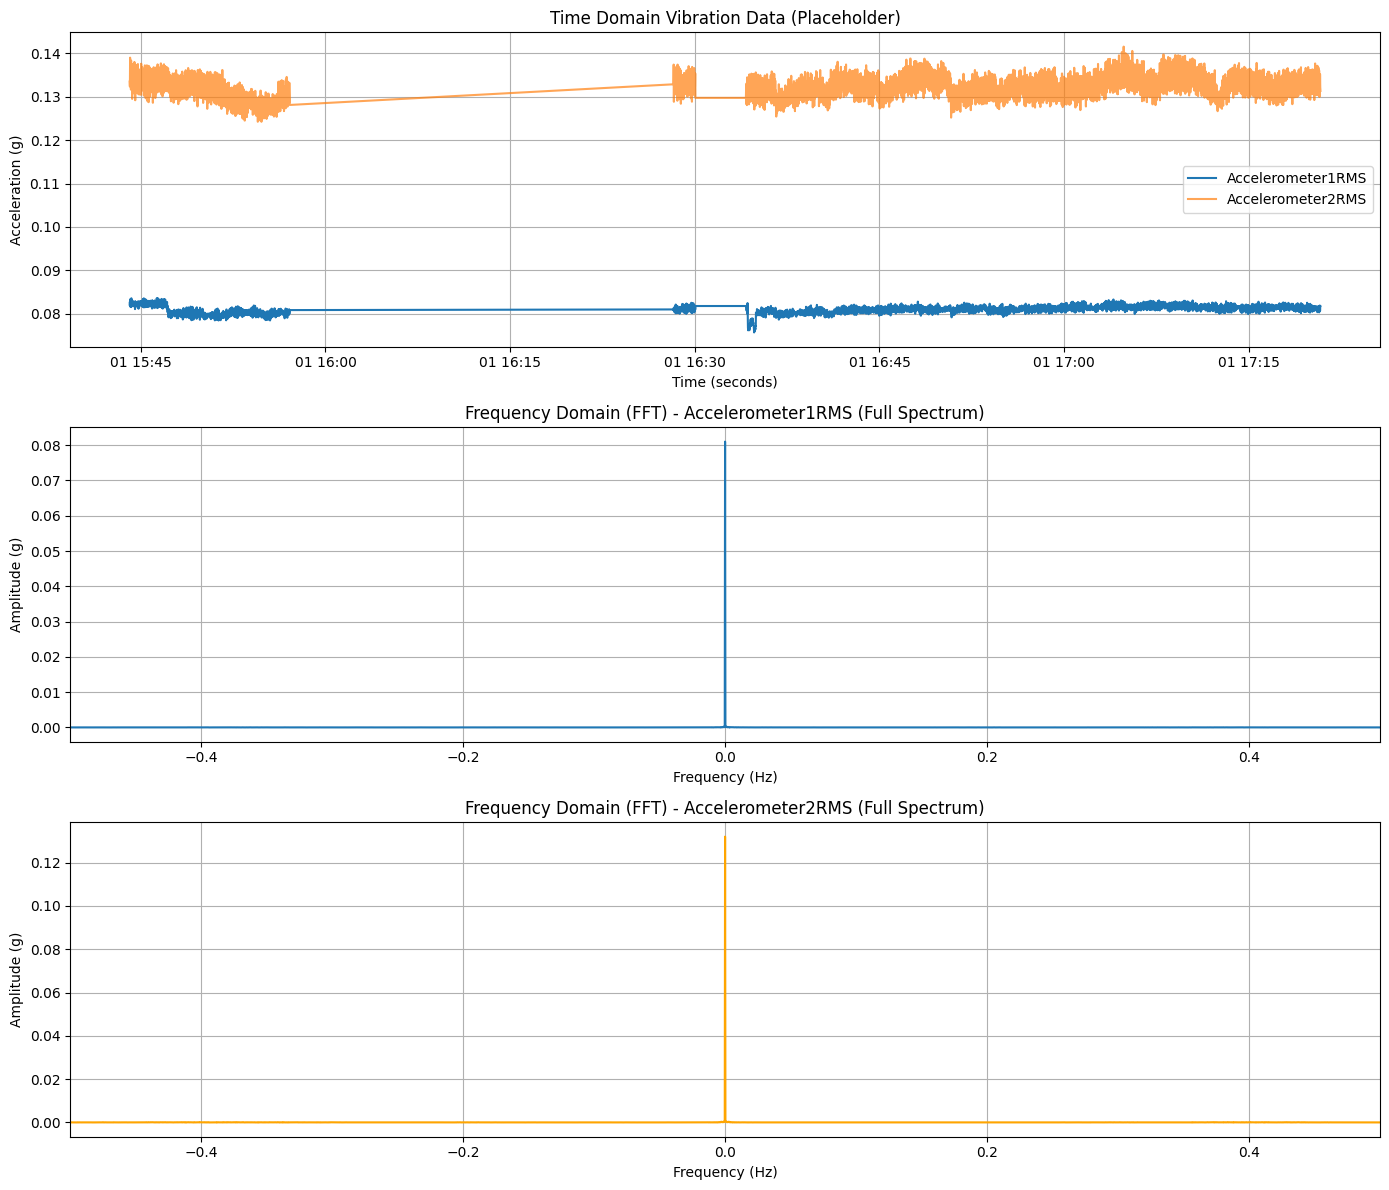


--- Interpretation of FFT Results (Full Spectrum) ---
The plots above now show the full frequency content, including both positive and negative frequencies.
The frequency range displayed is from -0.5 Hz to +0.5 Hz.
For real-valued signals, the magnitude spectrum is symmetric around 0 Hz, meaning the negative frequency components are a mirror image of the positive frequency components.

For Accelerometer1RMS (Positive Frequencies):
  Dominant positive frequency: 0.000 Hz with amplitude (single-sided): 0.162 g

For Accelerometer2RMS (Positive Frequencies):
  Dominant positive frequency: 0.000 Hz with amplitude (single-sided): 0.264 g

While the full spectrum shows symmetry, for practical interpretation of a real-valued signal, we usually focus on the positive frequencies because they contain all the unique information about the signal's frequency content.
Performing FFT for Accelerometer1RMS (including negative frequencies)...
Performing FFT for Accelerometer2RMS (including negative fre

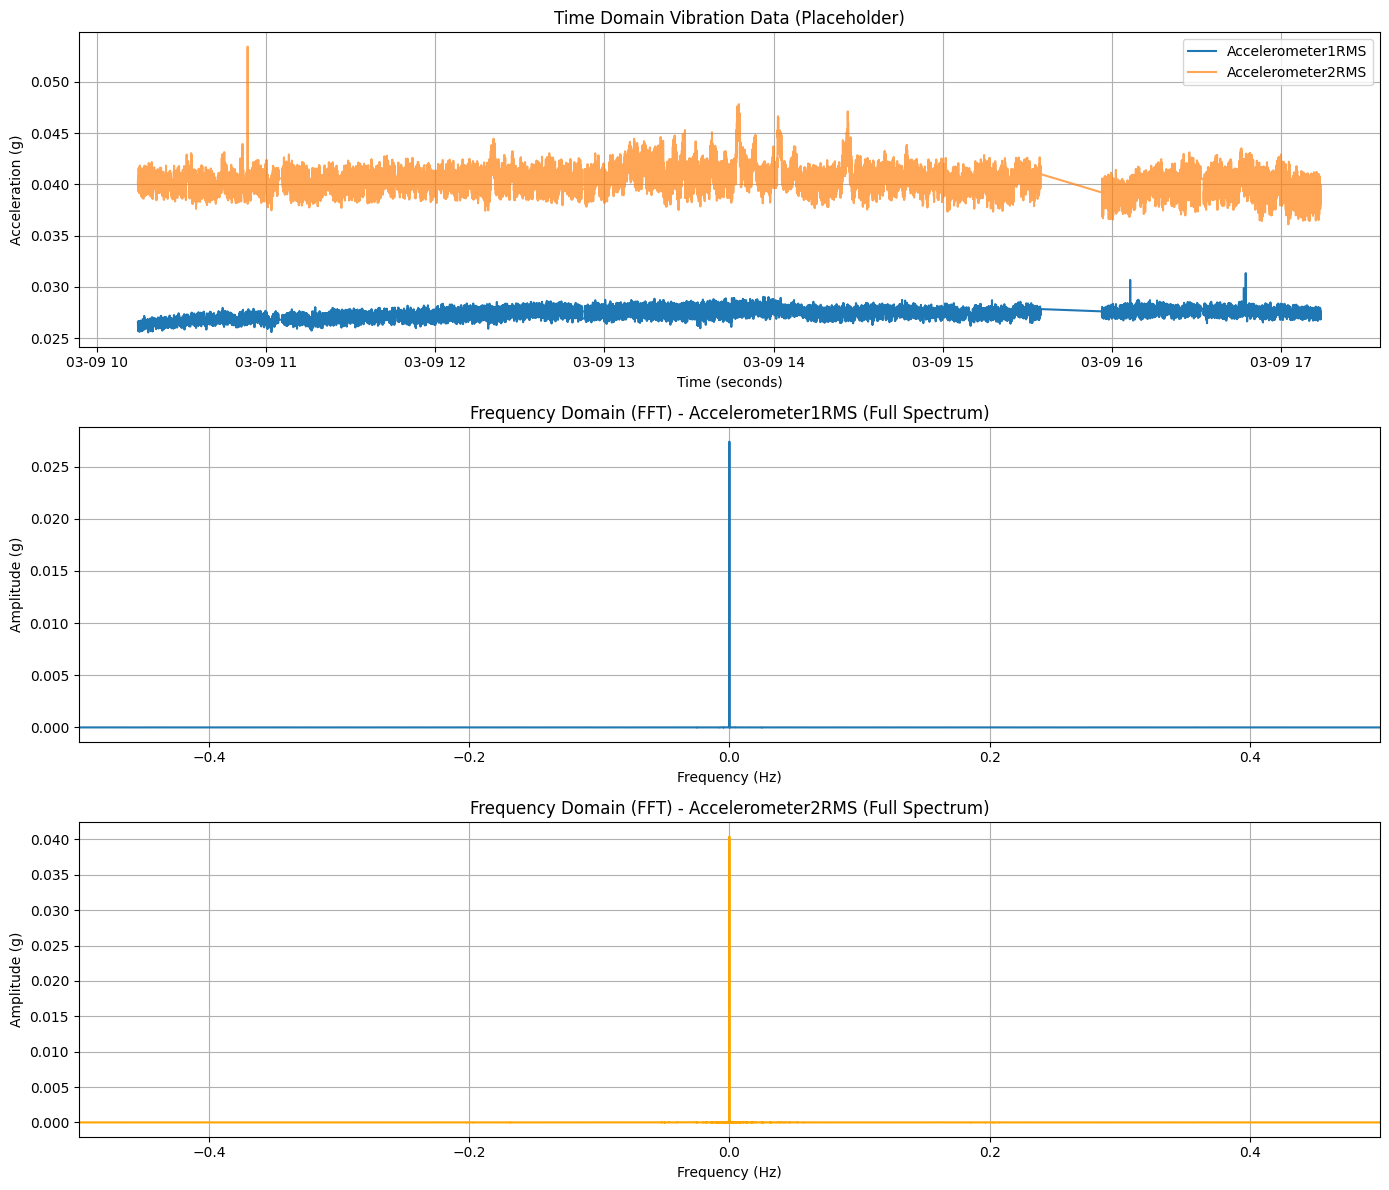


--- Interpretation of FFT Results (Full Spectrum) ---
The plots above now show the full frequency content, including both positive and negative frequencies.
The frequency range displayed is from -0.5 Hz to +0.5 Hz.
For real-valued signals, the magnitude spectrum is symmetric around 0 Hz, meaning the negative frequency components are a mirror image of the positive frequency components.

For Accelerometer1RMS (Positive Frequencies):
  Dominant positive frequency: 0.000 Hz with amplitude (single-sided): 0.055 g

For Accelerometer2RMS (Positive Frequencies):
  Dominant positive frequency: 0.000 Hz with amplitude (single-sided): 0.081 g

While the full spectrum shows symmetry, for practical interpretation of a real-valued signal, we usually focus on the positive frequencies because they contain all the unique information about the signal's frequency content.


In [6]:
fast_fourier_transform(dataframe["2020-02-08 00:00:00":"2020-02-08 23:59:59"])
fast_fourier_transform(dataframe["2020-03-01 00:00:00":"2020-03-01 23:59:59"])
fast_fourier_transform(dataframe["2020-03-09 00:00:00":"2020-03-09 23:59:59"])

**Explanation:**

1.  **Placeholder Data Generation**:

      * I've created `accel1_rms_placeholder` and `accel2_rms_placeholder` as NumPy arrays.
      * Each array simulates vibration data over 100 seconds (since the sampling rate is 1 Hz).
      * I've included a dominant sine wave and a secondary sine wave, plus some random noise, to make the FFT results interesting and realistic.

2.  **Sampling Rate and Time Step**:

      * `sampling_rate = 1` Hz means we have one data point every second.
      * `time_step = 1 / sampling_rate = 1` second.

3.  **Performing the FFT**:

      * `yf1 = fft(accel1_rms_placeholder)`: This computes the Discrete Fourier Transform (DFT) using the efficient Fast Fourier Transform algorithm for `Accelerometer1RMS`. The output `yf1` is a complex array.
      * `xf1 = fftfreq(num_samples, time_step)[:num_samples // 2]`: This generates the corresponding frequency bins for the FFT result. We only consider the first half (`[:num_samples // 2]`) because the second half is a mirror image for real-valued input data and represents negative frequencies.
      * `magnitude_spectrum1 = 2.0 / num_samples * np.abs(yf1[0:num_samples // 2])`: To get the physical amplitude (in 'g' units in this case), we take the absolute value of the complex FFT output and normalize it. We multiply by `2.0 / num_samples` because we're looking at a single-sided spectrum (only positive frequencies), and the energy from the negative frequencies is folded into the positive frequencies.

4.  **Plotting**:

      * The top plot shows the time-domain data, which is just the 'g' units over time.
      * The middle and bottom plots show the **magnitude spectrum** for each accelerometer. The x-axis is **Frequency (Hz)**, and the y-axis is **Amplitude (g)**. Peaks in these plots indicate the dominant frequencies present in the vibration data and their strength.

5.  **Interpretation**:

      * The Nyquist frequency is half of the sampling rate. In your case, with a 1 Hz sampling rate, you can accurately detect frequencies up to $0.5$ Hz. Frequencies above this would be subject to aliasing.
      * The code identifies the frequency with the highest amplitude (the dominant frequency) for each accelerometer, which is often the most important feature for vibration analysis.

This example provides a complete workflow for performing FFT on your vibration data. When you have your actual data, you would simply replace the `accel1_rms_placeholder` and `accel2_rms_placeholder` with your real data arrays.